# Semana 9 — Horizonte Rodante (RH): inventarios con demanda estacional

Esta sesión introduce el **horizonte rodante (RH)** como una estrategia de aproximación para MDP con demanda no estacionaria. Se comparan:

- backward induction sobre el horizonte completo de evaluación;
- una política estacionaria obtenida con iteración de valor;
- políticas RH con diferentes longitudes de ventana;
- una política RH con un valor terminal aproximado.

La progresión del cuaderno sigue la misma lógica de las semanas anteriores:

1. primero se desarrolla el cálculo con ciclos explícitos;
2. después se convierte en una función cuando debe repetirse;
3. las gráficas se entregan como apoyo visual y no como contenido de programación evaluable.

> 🧠 **Código central:** debe poder explicar su relación con el modelo.  
> 🧩 **Herramienta nueva:** se introduce antes de utilizarla.  
> 🎨 **Visualización proporcionada:** debe interpretar el resultado, pero no memorizar la sintaxis de Matplotlib.

---
## Fundamentos: RH como programación dinámica truncada

En backward induction se resuelve un horizonte completo conocido. En horizonte rodante, en cada período \(t\):

1. se observa el estado actual \(s_t\);
2. se resuelve un problema de \(H\) períodos;
3. se ejecuta **solo la primera acción**;
4. se observa el nuevo estado y se vuelve a resolver.

La recursión dentro de la ventana es:

$$
V_{t+k}(s)
=
\max_a
\left[
r_{t+k}(s,a)
+
\gamma
\sum_{s'}
P_{t+k}(s'|s,a)
V_{t+k+1}(s')
\right].
$$

Un horizonte pequeño puede producir **miopía**. Además, fijar \(\widehat V(s)=0\) puede generar un **sesgo de truncamiento**, porque se ignora el valor de los estados después de la ventana.

Un valor terminal aproximado puede reducir ese sesgo, pero no garantiza eliminarlo. Su utilidad depende de qué tan bien represente el futuro del problema real.

### Evaluación estadística

Todas las políticas se evaluarán sobre los **mismos escenarios de demanda**. Para comparar una política \(\pi\) con el benchmark, se calculará en cada simulación:

$$
D_i = R_i^\pi - R_i^{\mathrm{BI}}.
$$

El intervalo emparejado será:

$$
\overline D
\pm
1.96 \frac{s_D}{\sqrt{N}}.
$$

- Si el intervalo no contiene cero, se detecta una diferencia estadísticamente significativa.
- Si contiene cero, no se detecta una diferencia; esto no demuestra equivalencia.

In [1]:
# Ejecutar esta celda si jmarkov no está instalado.
!pip install jmarkov

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import matplotlib.pyplot as plt

---
## Problema: FerreAndes S.A.S.

FerreAndes distribuye tornillos de precisión. La demanda sigue un ciclo estacional de seis períodos:

| Período | Temporada | $\mathbb E[D]$ | Distribución |
|:---:|:---:|:---:|:---|
| 0, 1 | Baja | 0.80 | $P(D=0)=0.35,\ P(D=1)=0.50,\ P(D=2)=0.15$ |
| 2, 3 | Alta | 2.15 | $P(D=0)=0.05,\ P(D=1)=0.15,\ P(D=2)=0.40,\ P(D=3)=0.40$ |
| 4, 5 | Media | 1.30 | $P(D=0)=0.20,\ P(D=1)=0.40,\ P(D=2)=0.30,\ P(D=3)=0.10$ |

Parámetros:

- precio de venta: \$60;
- costo de pedido: \$22 por unidad;
- almacenamiento: \$7 por unidad sobrante;
- escasez: \$35 por unidad no atendida;
- capacidad máxima: 4 unidades.

La evaluación se hará durante **24 períodos**, equivalentes a cuatro ciclos. El benchmark exacto será backward induction resuelto sobre esos mismos 24 períodos.

In [3]:
# Parámetros del problema

T_CICLO = 6
T_SIM = 24

INVENTARIO_MAXIMO = 4
NUMERO_ESTADOS = INVENTARIO_MAXIMO + 1
NUMERO_ACCIONES = INVENTARIO_MAXIMO + 1

PRECIO = 60
COSTO_PEDIDO = 22
COSTO_ALMACENAMIENTO = 7
COSTO_ESCASEZ = 35

PENALIZACION_INFACTIBLE = -1000000

GAMMA_BI = 1.0
GAMMA_VI = 0.97

VALORES_DEMANDA = [0, 1, 2, 3]

PROBABILIDADES_DEMANDA = [
    [0.35, 0.50, 0.15, 0.00],
    [0.35, 0.50, 0.15, 0.00],
    [0.05, 0.15, 0.40, 0.40],
    [0.05, 0.15, 0.40, 0.40],
    [0.20, 0.40, 0.30, 0.10],
    [0.20, 0.40, 0.30, 0.10],
]

NOMBRES_TEMPORADA = [
    "Baja",
    "Baja",
    "Alta",
    "Alta",
    "Media",
    "Media",
]

medias_demanda = np.zeros(T_CICLO)

for periodo in range(T_CICLO):

    media_periodo = 0.0

    for indice_demanda in range(len(VALORES_DEMANDA)):

        demanda = VALORES_DEMANDA[indice_demanda]
        probabilidad = PROBABILIDADES_DEMANDA[
            periodo
        ][indice_demanda]

        media_periodo = (
            media_periodo
            + demanda * probabilidad
        )

    medias_demanda[periodo] = media_periodo

print("E[D] por período:", np.round(medias_demanda, 2))

E[D] por período: [0.8  0.8  2.15 2.15 1.3  1.3 ]


---
## Construcción de $(R_t)$ y $(P_t)$ para un período

Primero construiremos las recompensas y las transiciones del período \(t=0\), sin utilizar funciones.

Para un estado de inventario \(s\) y una acción \(a\):

$[
y=s+a
]$

es el inventario disponible después del pedido. Si \(y\) supera la capacidad, la acción es infactible.

Para cada demanda \(d\):

$[
s'=\max(0,y-d).
]$

La recompensa del período incluye ventas, pedido, almacenamiento y escasez.

In [4]:
# Construcción manual para t=0

probabilidades_t0 = PROBABILIDADES_DEMANDA[0]

retornos_t0 = np.zeros(
    (NUMERO_ESTADOS, NUMERO_ACCIONES)
)

transiciones_t0 = []

for estado_actual in range(NUMERO_ESTADOS):

    for accion_actual in range(NUMERO_ACCIONES):

        inventario_disponible = (
            estado_actual + accion_actual
        )

        if inventario_disponible > INVENTARIO_MAXIMO:

            retornos_t0[
                estado_actual,
                accion_actual
            ] = PENALIZACION_INFACTIBLE

        else:

            retorno_esperado = (
                -COSTO_PEDIDO * accion_actual
            )

            for indice_demanda in range(
                len(VALORES_DEMANDA)
            ):

                demanda = VALORES_DEMANDA[
                    indice_demanda
                ]

                probabilidad = probabilidades_t0[
                    indice_demanda
                ]

                ventas = min(
                    inventario_disponible,
                    demanda
                )

                sobrante = max(
                    0,
                    inventario_disponible - demanda
                )

                faltante = max(
                    0,
                    demanda - inventario_disponible
                )

                retorno_esperado = (
                    retorno_esperado
                    + probabilidad
                    * (
                        PRECIO * ventas
                        - COSTO_ALMACENAMIENTO * sobrante
                        - COSTO_ESCASEZ * faltante
                    )
                )

            retornos_t0[
                estado_actual,
                accion_actual
            ] = retorno_esperado


for accion_actual in range(NUMERO_ACCIONES):

    matriz_accion = np.zeros(
        (NUMERO_ESTADOS, NUMERO_ESTADOS)
    )

    for estado_actual in range(NUMERO_ESTADOS):

        inventario_disponible = (
            estado_actual + accion_actual
        )

        if inventario_disponible > INVENTARIO_MAXIMO:

            # Transición ficticia válida.
            matriz_accion[
                estado_actual,
                estado_actual
            ] = 1.0

        else:

            for indice_demanda in range(
                len(VALORES_DEMANDA)
            ):

                demanda = VALORES_DEMANDA[
                    indice_demanda
                ]

                probabilidad = probabilidades_t0[
                    indice_demanda
                ]

                estado_siguiente = max(
                    0,
                    inventario_disponible - demanda
                )

                matriz_accion[
                    estado_actual,
                    estado_siguiente
                ] = (
                    matriz_accion[
                        estado_actual,
                        estado_siguiente
                    ]
                    + probabilidad
                )

    transiciones_t0.append(matriz_accion)

print("R(t=0):")
print(np.round(retornos_t0, 2))

print("\nSuma de filas para la acción Pedir 0:")

for estado_actual in range(NUMERO_ESTADOS):

    suma_fila = transiciones_t0[0][
        estado_actual, :
    ].sum()

    print(
        "Estado",
        estado_actual,
        "->",
        round(float(suma_fila), 6)
    )

R(t=0):
[[-2.80e+01  9.30e+00 -4.40e+00 -3.34e+01 -6.24e+01]
 [ 3.13e+01  1.76e+01 -1.14e+01 -4.04e+01 -1.00e+06]
 [ 3.96e+01  1.06e+01 -1.84e+01 -1.00e+06 -1.00e+06]
 [ 3.26e+01  3.60e+00 -1.00e+06 -1.00e+06 -1.00e+06]
 [ 2.56e+01 -1.00e+06 -1.00e+06 -1.00e+06 -1.00e+06]]

Suma de filas para la acción Pedir 0:
Estado 0 -> 1.0
Estado 1 -> 1.0
Estado 2 -> 1.0
Estado 3 -> 1.0
Estado 4 -> 1.0


La construcción anterior debe repetirse para distintos períodos. Por eso se convierte ahora en dos funciones específicas del problema. Las funciones usan los parámetros ya definidos en el cuaderno y reciben únicamente la distribución de demanda del período.

In [5]:
def construir_retornos(probabilidades_demanda):

    retornos = np.zeros(
        (NUMERO_ESTADOS, NUMERO_ACCIONES)
    )

    for estado_actual in range(NUMERO_ESTADOS):

        for accion_actual in range(NUMERO_ACCIONES):

            inventario_disponible = (
                estado_actual + accion_actual
            )

            if (
                inventario_disponible
                > INVENTARIO_MAXIMO
            ):

                retornos[
                    estado_actual,
                    accion_actual
                ] = PENALIZACION_INFACTIBLE

            else:

                retorno_esperado = (
                    -COSTO_PEDIDO * accion_actual
                )

                for indice_demanda in range(
                    len(VALORES_DEMANDA)
                ):

                    demanda = VALORES_DEMANDA[
                        indice_demanda
                    ]

                    probabilidad = (
                        probabilidades_demanda[
                            indice_demanda
                        ]
                    )

                    ventas = min(
                        inventario_disponible,
                        demanda
                    )

                    sobrante = max(
                        0,
                        inventario_disponible - demanda
                    )

                    faltante = max(
                        0,
                        demanda - inventario_disponible
                    )

                    retorno_esperado = (
                        retorno_esperado
                        + probabilidad
                        * (
                            PRECIO * ventas
                            - COSTO_ALMACENAMIENTO
                              * sobrante
                            - COSTO_ESCASEZ
                              * faltante
                        )
                    )

                retornos[
                    estado_actual,
                    accion_actual
                ] = retorno_esperado

    return retornos


def construir_transiciones(
    probabilidades_demanda
):

    matrices_por_accion = []

    for accion_actual in range(NUMERO_ACCIONES):

        matriz_accion = np.zeros(
            (NUMERO_ESTADOS, NUMERO_ESTADOS)
        )

        for estado_actual in range(NUMERO_ESTADOS):

            inventario_disponible = (
                estado_actual + accion_actual
            )

            if (
                inventario_disponible
                > INVENTARIO_MAXIMO
            ):

                matriz_accion[
                    estado_actual,
                    estado_actual
                ] = 1.0

            else:

                for indice_demanda in range(
                    len(VALORES_DEMANDA)
                ):

                    demanda = VALORES_DEMANDA[
                        indice_demanda
                    ]

                    probabilidad = (
                        probabilidades_demanda[
                            indice_demanda
                        ]
                    )

                    estado_siguiente = max(
                        0,
                        inventario_disponible
                        - demanda
                    )

                    matriz_accion[
                        estado_actual,
                        estado_siguiente
                    ] = (
                        matriz_accion[
                            estado_actual,
                            estado_siguiente
                        ]
                        + probabilidad
                    )

        matrices_por_accion.append(
            matriz_accion
        )

    return matrices_por_accion


retornos_t0_funcion = construir_retornos(
    probabilidades_t0
)

transiciones_t0_funcion = (
    construir_transiciones(
        probabilidades_t0
    )
)

diferencia_retornos = np.max(
    np.abs(
        retornos_t0_funcion
        - retornos_t0
    )
)

diferencia_transiciones = 0.0

for accion_actual in range(NUMERO_ACCIONES):

    diferencia_accion = np.max(
        np.abs(
            transiciones_t0_funcion[
                accion_actual
            ]
            - transiciones_t0[
                accion_actual
            ]
        )
    )

    if (
        diferencia_accion
        > diferencia_transiciones
    ):
        diferencia_transiciones = (
            diferencia_accion
        )

print(
    "Máxima diferencia en R:",
    diferencia_retornos
)

print(
    "Máxima diferencia en P:",
    diferencia_transiciones
)

Máxima diferencia en R: 0.0
Máxima diferencia en P: 0.0


---
## Método 1 — Backward induction exacto para 24 períodos

La evaluación posterior utiliza 24 períodos. Por ello, el benchmark exacto se resuelve sobre esos mismos 24 períodos, repitiendo cuatro veces el ciclo estacional.

Esto evita llamar “exacta” a una política optimizada para seis períodos y repetida después fuera de su horizonte original.

In [6]:
# Construir las distribuciones para los 24 períodos.

probabilidades_24 = []

for periodo in range(T_SIM):

    periodo_del_ciclo = periodo % T_CICLO

    probabilidades_24.append(
        PROBABILIDADES_DEMANDA[
            periodo_del_ciclo
        ].copy()
    )


# Backward induction sobre los 24 períodos.

valor_siguiente = np.zeros(NUMERO_ESTADOS)

valor_bi = np.zeros(
    (T_SIM, NUMERO_ESTADOS)
)

politica_bi = np.zeros(
    (T_SIM, NUMERO_ESTADOS),
    dtype=int
)

for periodo in range(T_SIM - 1, -1, -1):

    retornos_periodo = construir_retornos(
        probabilidades_24[periodo]
    )

    transiciones_periodo = (
        construir_transiciones(
            probabilidades_24[periodo]
        )
    )

    valores_por_accion = np.zeros(
        (NUMERO_ESTADOS, NUMERO_ACCIONES)
    )

    for estado_actual in range(NUMERO_ESTADOS):

        for accion_actual in range(
            NUMERO_ACCIONES
        ):

            continuacion = 0.0

            for estado_siguiente in range(
                NUMERO_ESTADOS
            ):

                probabilidad = (
                    transiciones_periodo[
                        accion_actual
                    ][
                        estado_actual,
                        estado_siguiente
                    ]
                )

                continuacion = (
                    continuacion
                    + probabilidad
                    * valor_siguiente[
                        estado_siguiente
                    ]
                )

            valores_por_accion[
                estado_actual,
                accion_actual
            ] = (
                retornos_periodo[
                    estado_actual,
                    accion_actual
                ]
                + GAMMA_BI * continuacion
            )

    valor_actual = np.zeros(NUMERO_ESTADOS)

    for estado_actual in range(NUMERO_ESTADOS):

        mejor_accion = int(
            np.argmax(
                valores_por_accion[
                    estado_actual, :
                ]
            )
        )

        politica_bi[
            periodo,
            estado_actual
        ] = mejor_accion

        valor_actual[estado_actual] = (
            valores_por_accion[
                estado_actual,
                mejor_accion
            ]
        )

    valor_bi[periodo, :] = valor_actual

    valor_siguiente = valor_actual.copy()


print("Política BI exacta: primeros seis períodos")

for periodo in range(T_CICLO):

    print(
        "t =",
        periodo,
        NOMBRES_TEMPORADA[periodo],
        "->",
        politica_bi[periodo, :]
    )

print("\nPolítica BI exacta: últimos seis períodos")

for periodo in range(T_SIM - T_CICLO, T_SIM):

    periodo_del_ciclo = periodo % T_CICLO

    print(
        "t =",
        periodo,
        NOMBRES_TEMPORADA[
            periodo_del_ciclo
        ],
        "->",
        politica_bi[periodo, :]
    )

Política BI exacta: primeros seis períodos
t = 0 Baja -> [2 1 0 0 0]
t = 1 Baja -> [2 1 0 0 0]
t = 2 Alta -> [3 2 1 0 0]
t = 3 Alta -> [3 2 1 0 0]
t = 4 Media -> [3 2 1 0 0]
t = 5 Media -> [2 1 0 0 0]

Política BI exacta: últimos seis períodos
t = 18 Baja -> [2 1 0 0 0]
t = 19 Baja -> [2 1 0 0 0]
t = 20 Alta -> [3 2 1 0 0]
t = 21 Alta -> [3 2 1 0 0]
t = 22 Media -> [2 1 0 0 0]
t = 23 Media -> [2 1 0 0 0]


### Verificación proporcionada con `jmarkov`

La siguiente celda construye diccionarios porque esa es la interfaz requerida por `jmarkov`. Esta sintaxis no hace parte de la programación evaluada. El objetivo es comparar los valores producidos por la librería con los obtenidos mediante los ciclos anteriores.

In [7]:
from jmarkov.sdp.dtsdp import dtsdp

epocas_bi = np.array(
    list(range(1, T_SIM + 1))
)

estados_bi = np.array([
    "0", "1", "2", "3", "4"
])

acciones_bi = np.array([
    "Pedir 0",
    "Pedir 1",
    "Pedir 2",
    "Pedir 3",
    "Pedir 4",
])

probabilidades_bi_jmarkov = {}

retornos_bi_jmarkov = np.zeros(
    (
        T_SIM,
        NUMERO_ESTADOS,
        NUMERO_ACCIONES
    )
)

for periodo in range(T_SIM):

    retornos_periodo = construir_retornos(
        probabilidades_24[periodo]
    )

    transiciones_periodo = (
        construir_transiciones(
            probabilidades_24[periodo]
        )
    )

    retornos_bi_jmarkov[
        periodo, :, :
    ] = retornos_periodo

    matrices_del_periodo = {}

    for accion_actual in range(
        NUMERO_ACCIONES
    ):

        nombre_accion = acciones_bi[
            accion_actual
        ]

        matrices_del_periodo[
            nombre_accion
        ] = transiciones_periodo[
            accion_actual
        ]

    probabilidades_bi_jmarkov[
        epocas_bi[periodo]
    ] = matrices_del_periodo


modelo_bi = dtsdp(
    epocas_bi,
    estados_bi,
    acciones_bi,
    probabilidades_bi_jmarkov,
    retornos_bi_jmarkov,
    GAMMA_BI
)

valor_bi_jmarkov, _ = modelo_bi.solve(
    minimize=False
)

print(
    "V(t=0) con ciclos:",
    np.round(valor_bi[0, :], 3)
)

print(
    "V(t=0) con jmarkov:",
    np.round(
        np.array(
            valor_bi_jmarkov,
            dtype=float
        )[:, 0],
        3
    )
)

V(t=0) con ciclos: [1058.728 1080.728 1102.728 1115.278 1123.425]
V(t=0) con jmarkov: [1058.728 1080.728 1102.728 1115.278 1123.425]


---
## Método 2 — VI estacionaria con demanda promedio

Esta política ignora la posición dentro del ciclo y supone que la demanda sigue siempre la distribución promedio.

Se diseña con \(\gamma=0.97\), mientras que BI y RH usan \(\gamma=1\). Por tanto, VI es una referencia construida bajo un criterio diferente. Todas las políticas se evaluarán después con la misma medida: ingreso acumulado no descontado durante 24 períodos.

In [8]:
# Distribución promedio calculada sin axis.

probabilidades_promedio = []

for indice_demanda in range(
    len(VALORES_DEMANDA)
):

    suma_probabilidades = 0.0

    for periodo in range(T_CICLO):

        suma_probabilidades = (
            suma_probabilidades
            + PROBABILIDADES_DEMANDA[
                periodo
            ][indice_demanda]
        )

    promedio = (
        suma_probabilidades / T_CICLO
    )

    probabilidades_promedio.append(promedio)


retornos_vi = construir_retornos(
    probabilidades_promedio
)

transiciones_vi = construir_transiciones(
    probabilidades_promedio
)

tolerancia_vi = 0.000001
maximo_iteraciones_vi = 10000

valor_vi = np.zeros(NUMERO_ESTADOS)

numero_iteraciones_vi = 0

while True:

    numero_iteraciones_vi = (
        numero_iteraciones_vi + 1
    )

    valores_por_accion = np.zeros(
        (NUMERO_ESTADOS, NUMERO_ACCIONES)
    )

    for estado_actual in range(NUMERO_ESTADOS):

        for accion_actual in range(
            NUMERO_ACCIONES
        ):

            continuacion = 0.0

            for estado_siguiente in range(
                NUMERO_ESTADOS
            ):

                continuacion = (
                    continuacion
                    + transiciones_vi[
                        accion_actual
                    ][
                        estado_actual,
                        estado_siguiente
                    ]
                    * valor_vi[
                        estado_siguiente
                    ]
                )

            valores_por_accion[
                estado_actual,
                accion_actual
            ] = (
                retornos_vi[
                    estado_actual,
                    accion_actual
                ]
                + GAMMA_VI * continuacion
            )

    valor_nuevo = np.zeros(NUMERO_ESTADOS)

    for estado_actual in range(NUMERO_ESTADOS):

        valor_nuevo[estado_actual] = np.max(
            valores_por_accion[
                estado_actual, :
            ]
        )

    cambio_maximo = np.max(
        np.abs(valor_nuevo - valor_vi)
    )

    valor_vi = valor_nuevo.copy()

    if cambio_maximo < tolerancia_vi:
        break

    if (
        numero_iteraciones_vi
        >= maximo_iteraciones_vi
    ):
        break


# Recalcular los valores por acción con el V final.

valores_finales_vi = np.zeros(
    (NUMERO_ESTADOS, NUMERO_ACCIONES)
)

politica_vi = np.zeros(
    NUMERO_ESTADOS,
    dtype=int
)

for estado_actual in range(NUMERO_ESTADOS):

    for accion_actual in range(
        NUMERO_ACCIONES
    ):

        continuacion = 0.0

        for estado_siguiente in range(
            NUMERO_ESTADOS
        ):

            continuacion = (
                continuacion
                + transiciones_vi[
                    accion_actual
                ][
                    estado_actual,
                    estado_siguiente
                ]
                * valor_vi[
                    estado_siguiente
                ]
            )

        valores_finales_vi[
            estado_actual,
            accion_actual
        ] = (
            retornos_vi[
                estado_actual,
                accion_actual
            ]
            + GAMMA_VI * continuacion
        )

    politica_vi[estado_actual] = np.argmax(
        valores_finales_vi[
            estado_actual, :
        ]
    )


print(
    "VI convergió en",
    numero_iteraciones_vi,
    "actualizaciones."
)

print("Política VI estacionaria:")

for estado_actual in range(NUMERO_ESTADOS):

    print(
        "Inventario",
        estado_actual,
        "-> pedir",
        politica_vi[estado_actual]
    )

print("V*:", np.round(valor_vi, 2))

VI convergió en 578 actualizaciones.
Política VI estacionaria:
Inventario 0 -> pedir 3
Inventario 1 -> pedir 2
Inventario 2 -> pedir 1
Inventario 3 -> pedir 0
Inventario 4 -> pedir 0
V*: [1390.17 1412.17 1434.17 1456.17 1468.66]


---
## Método 3 — Horizonte rodante

### RH con \(H=1\)

Con una ventana de un período y valor terminal cero:

\[
Q_t(s,a)=r_t(s,a).
\]

Calcularemos la política en \(t=1\), el último período de temporada baja antes del inicio de la temporada alta.

In [9]:
periodo_inicial = 1

retornos_rh1 = construir_retornos(
    PROBABILIDADES_DEMANDA[
        periodo_inicial
    ]
)

transiciones_rh1 = construir_transiciones(
    PROBABILIDADES_DEMANDA[
        periodo_inicial
    ]
)

valor_terminal_cero = np.zeros(
    NUMERO_ESTADOS
)

valores_rh1 = np.zeros(
    (NUMERO_ESTADOS, NUMERO_ACCIONES)
)

politica_rh1_manual = np.zeros(
    NUMERO_ESTADOS,
    dtype=int
)

for estado_actual in range(NUMERO_ESTADOS):

    for accion_actual in range(
        NUMERO_ACCIONES
    ):

        continuacion = 0.0

        for estado_siguiente in range(
            NUMERO_ESTADOS
        ):

            continuacion = (
                continuacion
                + transiciones_rh1[
                    accion_actual
                ][
                    estado_actual,
                    estado_siguiente
                ]
                * valor_terminal_cero[
                    estado_siguiente
                ]
            )

        valores_rh1[
            estado_actual,
            accion_actual
        ] = (
            retornos_rh1[
                estado_actual,
                accion_actual
            ]
            + GAMMA_BI * continuacion
        )

    politica_rh1_manual[
        estado_actual
    ] = np.argmax(
        valores_rh1[
            estado_actual, :
        ]
    )

print(
    "RH-H=1 en t=1:",
    politica_rh1_manual
)

RH-H=1 en t=1: [1 0 0 0 0]


### RH con \(H=2\)

Ahora la ventana cubre los períodos \(t=1\) y \(t=2\).

1. Se resuelve primero el período \(t=2\), usando valor terminal cero.
2. Ese valor se utiliza como continuación al resolver \(t=1\).
3. Se conserva únicamente la acción correspondiente a \(t=1\).

Esta celda muestra explícitamente la lógica que después se repetirá en la función general.

In [10]:
# Paso 1: resolver el último período de la ventana.

periodo_final_ventana = 2

retornos_final = construir_retornos(
    PROBABILIDADES_DEMANDA[
        periodo_final_ventana
    ]
)

transiciones_final = construir_transiciones(
    PROBABILIDADES_DEMANDA[
        periodo_final_ventana
    ]
)

valores_final = np.zeros(
    (NUMERO_ESTADOS, NUMERO_ACCIONES)
)

valor_periodo_final = np.zeros(
    NUMERO_ESTADOS
)

for estado_actual in range(NUMERO_ESTADOS):

    for accion_actual in range(
        NUMERO_ACCIONES
    ):

        continuacion = 0.0

        for estado_siguiente in range(
            NUMERO_ESTADOS
        ):

            continuacion = (
                continuacion
                + transiciones_final[
                    accion_actual
                ][
                    estado_actual,
                    estado_siguiente
                ]
                * valor_terminal_cero[
                    estado_siguiente
                ]
            )

        valores_final[
            estado_actual,
            accion_actual
        ] = (
            retornos_final[
                estado_actual,
                accion_actual
            ]
            + GAMMA_BI * continuacion
        )

    valor_periodo_final[estado_actual] = (
        np.max(
            valores_final[
                estado_actual, :
            ]
        )
    )


# Paso 2: resolver el primer período de la ventana.

retornos_inicial = construir_retornos(
    PROBABILIDADES_DEMANDA[
        periodo_inicial
    ]
)

transiciones_inicial = (
    construir_transiciones(
        PROBABILIDADES_DEMANDA[
            periodo_inicial
        ]
    )
)

valores_inicial = np.zeros(
    (NUMERO_ESTADOS, NUMERO_ACCIONES)
)

politica_rh2_manual = np.zeros(
    NUMERO_ESTADOS,
    dtype=int
)

for estado_actual in range(NUMERO_ESTADOS):

    for accion_actual in range(
        NUMERO_ACCIONES
    ):

        continuacion = 0.0

        for estado_siguiente in range(
            NUMERO_ESTADOS
        ):

            continuacion = (
                continuacion
                + transiciones_inicial[
                    accion_actual
                ][
                    estado_actual,
                    estado_siguiente
                ]
                * valor_periodo_final[
                    estado_siguiente
                ]
            )

        valores_inicial[
            estado_actual,
            accion_actual
        ] = (
            retornos_inicial[
                estado_actual,
                accion_actual
            ]
            + GAMMA_BI * continuacion
        )

    politica_rh2_manual[
        estado_actual
    ] = np.argmax(
        valores_inicial[
            estado_actual, :
        ]
    )

print(
    "RH-H=2 en t=1:",
    politica_rh2_manual
)

RH-H=2 en t=1: [2 1 0 0 0]


### Función general para RH

El operador `%` permite recorrer cíclicamente los períodos:

```python
periodo_del_ciclo = periodo % T_CICLO
```

Después del período 5, el siguiente vuelve a ser el período 0.

Como el patrón de demanda es periódico y conocido, podemos precalcular la acción RH para cada combinación de:

- período dentro del ciclo;
- estado de inventario.

Conceptualmente, RH sigue reoptimizando después de observar cada nuevo estado. La precalculación solo evita repetir cálculos idénticos.

In [11]:
def calcular_politica_rh(
    horizonte,
    valor_terminal
):

    politica = np.zeros(
        (T_CICLO, NUMERO_ESTADOS),
        dtype=int
    )

    for periodo_inicial in range(T_CICLO):

        valor_siguiente = (
            valor_terminal.copy()
        )

        valores_primera_etapa = np.zeros(
            (
                NUMERO_ESTADOS,
                NUMERO_ACCIONES
            )
        )

        for desplazamiento in range(
            horizonte - 1,
            -1,
            -1
        ):

            periodo_del_ciclo = (
                periodo_inicial
                + desplazamiento
            ) % T_CICLO

            retornos_periodo = (
                construir_retornos(
                    PROBABILIDADES_DEMANDA[
                        periodo_del_ciclo
                    ]
                )
            )

            transiciones_periodo = (
                construir_transiciones(
                    PROBABILIDADES_DEMANDA[
                        periodo_del_ciclo
                    ]
                )
            )

            valores_por_accion = np.zeros(
                (
                    NUMERO_ESTADOS,
                    NUMERO_ACCIONES
                )
            )

            for estado_actual in range(
                NUMERO_ESTADOS
            ):

                for accion_actual in range(
                    NUMERO_ACCIONES
                ):

                    continuacion = 0.0

                    for estado_siguiente in range(
                        NUMERO_ESTADOS
                    ):

                        continuacion = (
                            continuacion
                            + transiciones_periodo[
                                accion_actual
                            ][
                                estado_actual,
                                estado_siguiente
                            ]
                            * valor_siguiente[
                                estado_siguiente
                            ]
                        )

                    valores_por_accion[
                        estado_actual,
                        accion_actual
                    ] = (
                        retornos_periodo[
                            estado_actual,
                            accion_actual
                        ]
                        + GAMMA_BI * continuacion
                    )

            valor_actual = np.zeros(
                NUMERO_ESTADOS
            )

            for estado_actual in range(
                NUMERO_ESTADOS
            ):

                valor_actual[estado_actual] = (
                    np.max(
                        valores_por_accion[
                            estado_actual, :
                        ]
                    )
                )

            if desplazamiento == 0:

                valores_primera_etapa = (
                    valores_por_accion.copy()
                )

            valor_siguiente = (
                valor_actual.copy()
            )

        for estado_actual in range(
            NUMERO_ESTADOS
        ):

            politica[
                periodo_inicial,
                estado_actual
            ] = np.argmax(
                valores_primera_etapa[
                    estado_actual, :
                ]
            )

    return politica


politica_rh1 = calcular_politica_rh(
    1,
    valor_terminal_cero
)

politica_rh2 = calcular_politica_rh(
    2,
    valor_terminal_cero
)

print(
    "RH-1 función en t=1:",
    politica_rh1[1, :]
)

print(
    "RH-1 manual en t=1:",
    politica_rh1_manual
)

print(
    "RH-2 función en t=1:",
    politica_rh2[1, :]
)

print(
    "RH-2 manual en t=1:",
    politica_rh2_manual
)

RH-1 función en t=1: [1 0 0 0 0]
RH-1 manual en t=1: [1 0 0 0 0]
RH-2 función en t=1: [2 1 0 0 0]
RH-2 manual en t=1: [2 1 0 0 0]


In [12]:
politica_rh3 = calcular_politica_rh(
    3,
    valor_terminal_cero
)

politica_rh6 = calcular_politica_rh(
    6,
    valor_terminal_cero
)

print(
    "Comparación en t=1, antes de temporada alta"
)

for estado_actual in range(NUMERO_ESTADOS):

    print(
        "Inventario",
        estado_actual,
        "| BI exacto 24:",
        politica_bi[1, estado_actual],
        "| VI:",
        politica_vi[estado_actual],
        "| RH-1:",
        politica_rh1[1, estado_actual],
        "| RH-2:",
        politica_rh2[1, estado_actual],
        "| RH-3:",
        politica_rh3[1, estado_actual],
        "| RH-6:",
        politica_rh6[1, estado_actual]
    )

Comparación en t=1, antes de temporada alta
Inventario 0 | BI exacto 24: 2 | VI: 3 | RH-1: 1 | RH-2: 2 | RH-3: 2 | RH-6: 2
Inventario 1 | BI exacto 24: 1 | VI: 2 | RH-1: 0 | RH-2: 1 | RH-3: 1 | RH-6: 1
Inventario 2 | BI exacto 24: 0 | VI: 1 | RH-1: 0 | RH-2: 0 | RH-3: 0 | RH-6: 0
Inventario 3 | BI exacto 24: 0 | VI: 0 | RH-1: 0 | RH-2: 0 | RH-3: 0 | RH-6: 0
Inventario 4 | BI exacto 24: 0 | VI: 0 | RH-1: 0 | RH-2: 0 | RH-3: 0 | RH-6: 0


### Interpretación

- RH-\(H=1\) solo ve el retorno inmediato y resulta más miope.
- RH-\(H=2\) ya alcanza a ver el comienzo de la temporada alta.
- Aumentar \(H\) puede acercar la política al benchmark, pero no garantiza que RH-\(H=6\) coincida exactamente con BI.

RH-\(H=6\) siempre mira seis períodos desde el período actual y puede entrar al ciclo siguiente. En cambio, el benchmark BI termina exactamente después del período 23.

---
## Simulación Monte Carlo

Primero se simula un solo episodio con la política BI exacta. Después se generan escenarios comunes de demanda para todas las políticas.

Usar los mismos escenarios permite hacer comparaciones emparejadas.

In [13]:
# Un episodio manual bajo BI exacto.

generador_manual = np.random.default_rng(
    seed=42
)

inventario_actual = 0
retorno_total_manual = 0.0

demandas_manual = np.zeros(
    T_SIM,
    dtype=int
)

for periodo in range(T_SIM):

    periodo_del_ciclo = periodo % T_CICLO

    accion_actual = int(
        politica_bi[
            periodo,
            inventario_actual
        ]
    )

    inventario_disponible = (
        inventario_actual + accion_actual
    )

    probabilidades_periodo = (
        PROBABILIDADES_DEMANDA[
            periodo_del_ciclo
        ]
    )

    demanda = int(
        generador_manual.choice(
            VALORES_DEMANDA,
            p=probabilidades_periodo
        )
    )

    demandas_manual[periodo] = demanda

    ventas = min(
        inventario_disponible,
        demanda
    )

    sobrante = max(
        0,
        inventario_disponible - demanda
    )

    faltante = max(
        0,
        demanda - inventario_disponible
    )

    retorno_periodo = (
        PRECIO * ventas
        - COSTO_PEDIDO * accion_actual
        - COSTO_ALMACENAMIENTO * sobrante
        - COSTO_ESCASEZ * faltante
    )

    retorno_total_manual = (
        retorno_total_manual
        + retorno_periodo
    )

    inventario_siguiente = max(
        0,
        inventario_disponible - demanda
    )

    if periodo < 6:

        print(
            "t =",
            periodo,
            "| pedir:",
            accion_actual,
            "| disponible:",
            inventario_disponible,
            "| demanda:",
            demanda,
            "| retorno:",
            round(retorno_periodo, 1),
            "| siguiente:",
            inventario_siguiente
        )

    inventario_actual = inventario_siguiente

print(
    "\nRetorno total del episodio:",
    round(retorno_total_manual, 2)
)

t = 0 | pedir: 2 | disponible: 2 | demanda: 1 | retorno: 9 | siguiente: 1
t = 1 | pedir: 1 | disponible: 2 | demanda: 1 | retorno: 31 | siguiente: 1
t = 2 | pedir: 2 | disponible: 3 | demanda: 3 | retorno: 136 | siguiente: 0
t = 3 | pedir: 3 | disponible: 3 | demanda: 3 | retorno: 114 | siguiente: 0
t = 4 | pedir: 3 | disponible: 3 | demanda: 0 | retorno: -87 | siguiente: 3
t = 5 | pedir: 0 | disponible: 3 | demanda: 3 | retorno: 180 | siguiente: 0

Retorno total del episodio: 1175.0


Ahora se definen tres funciones sencillas:

1. expandir una política cíclica a 24 períodos;
2. generar escenarios comunes de demanda;
3. simular una política sobre esos escenarios.

In [14]:
def expandir_politica_ciclica(
    politica_ciclo,
    numero_periodos
):

    politica_expandida = np.zeros(
        (numero_periodos, NUMERO_ESTADOS),
        dtype=int
    )

    for periodo in range(numero_periodos):

        periodo_del_ciclo = periodo % T_CICLO

        for estado_actual in range(
            NUMERO_ESTADOS
        ):

            politica_expandida[
                periodo,
                estado_actual
            ] = politica_ciclo[
                periodo_del_ciclo,
                estado_actual
            ]

    return politica_expandida


def generar_escenarios_demanda(
    numero_simulaciones,
    numero_periodos,
    semilla
):

    generador = np.random.default_rng(
        seed=semilla
    )

    escenarios = np.zeros(
        (
            numero_simulaciones,
            numero_periodos
        ),
        dtype=int
    )

    for simulacion in range(
        numero_simulaciones
    ):

        for periodo in range(
            numero_periodos
        ):

            periodo_del_ciclo = (
                periodo % T_CICLO
            )

            escenarios[
                simulacion,
                periodo
            ] = int(
                generador.choice(
                    VALORES_DEMANDA,
                    p=PROBABILIDADES_DEMANDA[
                        periodo_del_ciclo
                    ]
                )
            )

    return escenarios


def simular_politica(
    politica,
    escenarios,
    inventario_inicial
):

    numero_simulaciones = (
        escenarios.shape[0]
    )

    numero_periodos = escenarios.shape[1]

    retornos = np.zeros(
        numero_simulaciones
    )

    for simulacion in range(
        numero_simulaciones
    ):

        inventario_actual = (
            inventario_inicial
        )

        retorno_total = 0.0

        for periodo in range(
            numero_periodos
        ):

            accion_actual = int(
                politica[
                    periodo,
                    inventario_actual
                ]
            )

            inventario_disponible = (
                inventario_actual
                + accion_actual
            )

            demanda = int(
                escenarios[
                    simulacion,
                    periodo
                ]
            )

            ventas = min(
                inventario_disponible,
                demanda
            )

            sobrante = max(
                0,
                inventario_disponible
                - demanda
            )

            faltante = max(
                0,
                demanda
                - inventario_disponible
            )

            retorno_periodo = (
                PRECIO * ventas
                - COSTO_PEDIDO
                  * accion_actual
                - COSTO_ALMACENAMIENTO
                  * sobrante
                - COSTO_ESCASEZ
                  * faltante
            )

            retorno_total = (
                retorno_total
                + retorno_periodo
            )

            inventario_actual = max(
                0,
                inventario_disponible
                - demanda
            )

        retornos[simulacion] = (
            retorno_total
        )

    return retornos

In [15]:
# Verificación con el episodio manual.

escenario_manual = np.zeros(
    (1, T_SIM),
    dtype=int
)

for periodo in range(T_SIM):

    escenario_manual[0, periodo] = (
        demandas_manual[periodo]
    )

retorno_verificacion = simular_politica(
    politica_bi,
    escenario_manual,
    inventario_inicial=0
)

print(
    "Retorno manual:",
    round(retorno_total_manual, 2)
)

print(
    "Retorno con función:",
    round(retorno_verificacion[0], 2)
)

print(
    "Coinciden:",
    np.isclose(
        retorno_total_manual,
        retorno_verificacion[0]
    )
)

Retorno manual: 1175.0
Retorno con función: 1175.0
Coinciden: True


### Evaluación de las políticas

Todas las políticas se transforman en matrices de tamaño:

\[
24\times 5.
\]

Así, la simulación siempre consulta:

```python
politica[periodo, estado]
```

y no necesita funciones `lambda`, diccionarios de funciones ni casos especiales.

In [16]:
NUMERO_SIMULACIONES = 2000
INVENTARIO_INICIAL = 0

politica_vi_24 = np.zeros(
    (T_SIM, NUMERO_ESTADOS),
    dtype=int
)

for periodo in range(T_SIM):

    for estado_actual in range(
        NUMERO_ESTADOS
    ):

        politica_vi_24[
            periodo,
            estado_actual
        ] = politica_vi[estado_actual]


politica_rh1_24 = (
    expandir_politica_ciclica(
        politica_rh1,
        T_SIM
    )
)

politica_rh2_24 = (
    expandir_politica_ciclica(
        politica_rh2,
        T_SIM
    )
)

politica_rh3_24 = (
    expandir_politica_ciclica(
        politica_rh3,
        T_SIM
    )
)

politica_rh6_24 = (
    expandir_politica_ciclica(
        politica_rh6,
        T_SIM
    )
)


escenarios_comunes = (
    generar_escenarios_demanda(
        NUMERO_SIMULACIONES,
        T_SIM,
        semilla=42
    )
)


nombres_politicas = [
    "BI exacto 24",
    "VI estacionaria",
    "RH-H=1",
    "RH-H=2",
    "RH-H=3",
    "RH-H=6",
]

matrices_politicas = [
    politica_bi,
    politica_vi_24,
    politica_rh1_24,
    politica_rh2_24,
    politica_rh3_24,
    politica_rh6_24,
]

retornos_politicas = []

for indice_politica in range(
    len(matrices_politicas)
):

    retornos = simular_politica(
        matrices_politicas[
            indice_politica
        ],
        escenarios_comunes,
        INVENTARIO_INICIAL
    )

    retornos_politicas.append(retornos)


print("Resultados marginales e intervalos emparejados")

retornos_benchmark = retornos_politicas[0]

for indice_politica in range(
    len(nombres_politicas)
):

    retornos = retornos_politicas[
        indice_politica
    ]

    media = np.mean(retornos)

    desviacion = np.std(
        retornos,
        ddof=1
    )

    error_estandar = (
        desviacion
        / np.sqrt(NUMERO_SIMULACIONES)
    )

    margen = 1.96 * error_estandar

    print("\n", nombres_politicas[indice_politica])

    print(
        "Media:",
        round(float(media), 2)
    )

    print(
        "IC marginal 95%: [",
        round(float(media - margen), 2),
        ",",
        round(float(media + margen), 2),
        "]"
    )

    if indice_politica > 0:

        diferencias = (
            retornos
            - retornos_benchmark
        )

        media_diferencia = np.mean(
            diferencias
        )

        desviacion_diferencia = np.std(
            diferencias,
            ddof=1
        )

        error_diferencia = (
            desviacion_diferencia
            / np.sqrt(
                NUMERO_SIMULACIONES
            )
        )

        margen_diferencia = (
            1.96 * error_diferencia
        )

        limite_inferior = (
            media_diferencia
            - margen_diferencia
        )

        limite_superior = (
            media_diferencia
            + margen_diferencia
        )

        print(
            "Diferencia media vs BI:",
            round(
                float(media_diferencia),
                2
            )
        )

        print(
            "IC emparejado 95%: [",
            round(
                float(limite_inferior),
                2
            ),
            ",",
            round(
                float(limite_superior),
                2
            ),
            "]"
        )

Resultados marginales e intervalos emparejados

 BI exacto 24
Media: 1061.08
IC marginal 95%: [ 1053.4 , 1068.76 ]

 VI estacionaria
Media: 991.95
IC marginal 95%: [ 983.85 , 1000.06 ]
Diferencia media vs BI: -69.13
IC emparejado 95%: [ -71.53 , -66.73 ]

 RH-H=1
Media: 1022.94
IC marginal 95%: [ 1016.11 , 1029.76 ]
Diferencia media vs BI: -38.14
IC emparejado 95%: [ -42.04 , -34.25 ]

 RH-H=2
Media: 1058.68
IC marginal 95%: [ 1051.26 , 1066.1 ]
Diferencia media vs BI: -2.4
IC emparejado 95%: [ -4.37 , -0.43 ]

 RH-H=3
Media: 1058.68
IC marginal 95%: [ 1051.26 , 1066.1 ]
Diferencia media vs BI: -2.4
IC emparejado 95%: [ -4.37 , -0.43 ]

 RH-H=6
Media: 1059.15
IC marginal 95%: [ 1051.3 , 1067.0 ]
Diferencia media vs BI: -1.93
IC emparejado 95%: [ -3.23 , -0.64 ]


### 🎨 Visualización proporcionada

La celda siguiente resume las medias y sus intervalos marginales. No se evalúa la sintaxis de Matplotlib.

La conclusión estadística debe basarse en los intervalos **emparejados de las diferencias** calculados en la celda anterior, no únicamente en el solapamiento de estas barras.

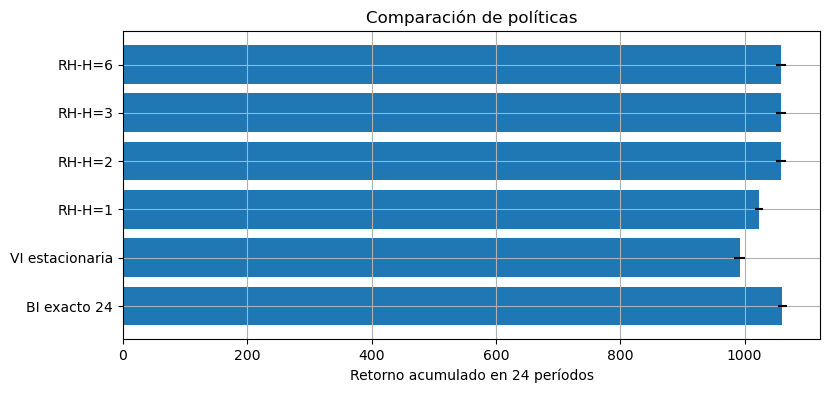

In [17]:
medias_grafica = np.zeros(
    len(nombres_politicas)
)

margenes_grafica = np.zeros(
    len(nombres_politicas)
)

for indice_politica in range(
    len(nombres_politicas)
):

    retornos = retornos_politicas[
        indice_politica
    ]

    medias_grafica[
        indice_politica
    ] = np.mean(retornos)

    error_estandar = (
        np.std(retornos, ddof=1)
        / np.sqrt(NUMERO_SIMULACIONES)
    )

    margenes_grafica[
        indice_politica
    ] = 1.96 * error_estandar


plt.figure(figsize=(9, 4))

plt.barh(
    nombres_politicas,
    medias_grafica,
    xerr=margenes_grafica
)

plt.xlabel(
    "Retorno acumulado en 24 períodos"
)

plt.title(
    "Comparación de políticas"
)

plt.grid()

plt.show()

---
## Valor terminal aproximado

La VI fue calculada con $(\gamma=0.97)$, mientras que RH utiliza $\gamma=1$. Por tanto, $V^{\mathrm{VI}}$ se usará únicamente como una **heurística terminal**.

Como sumar la misma constante a todos los estados terminales no cambia la elección de acciones, se utiliza:

$$
\widehat V(s)
=
V^{\mathrm{VI}}(s)
-
\min_x V^{\mathrm{VI}}(x).
$$

Esto conserva las diferencias relativas entre estados y evita introducir un nivel absoluto innecesariamente grande.

In [18]:
valor_terminal_vi = (
    valor_vi - np.min(valor_vi)
)

politica_rh2_terminal = (
    calcular_politica_rh(
        2,
        valor_terminal_vi
    )
)

politica_rh2_terminal_24 = (
    expandir_politica_ciclica(
        politica_rh2_terminal,
        T_SIM
    )
)

retornos_rh2_terminal = (
    simular_politica(
        politica_rh2_terminal_24,
        escenarios_comunes,
        INVENTARIO_INICIAL
    )
)

retornos_rh2_cero = (
    retornos_politicas[3]
)

diferencias_terminal = (
    retornos_rh2_terminal
    - retornos_rh2_cero
)

media_mejora = np.mean(
    diferencias_terminal
)

error_mejora = (
    np.std(
        diferencias_terminal,
        ddof=1
    )
    / np.sqrt(NUMERO_SIMULACIONES)
)

margen_mejora = 1.96 * error_mejora

print(
    "RH-2 con terminal cero:",
    round(
        float(
            np.mean(retornos_rh2_cero)
        ),
        2
    )
)

print(
    "RH-2 con terminal VI:",
    round(
        float(
            np.mean(
                retornos_rh2_terminal
            )
        ),
        2
    )
)

print(
    "Mejora media emparejada:",
    round(float(media_mejora), 2)
)

print(
    "IC 95% para la mejora: [",
    round(
        float(
            media_mejora - margen_mejora
        ),
        2
    ),
    ",",
    round(
        float(
            media_mejora + margen_mejora
        ),
        2
    ),
    "]"
)

RH-2 con terminal cero: 1058.68
RH-2 con terminal VI: 1059.15
Mejora media emparejada: 0.47
IC 95% para la mejora: [ -1.92 , 2.86 ]


La función terminal puede cambiar algunas acciones y puede mejorar el desempeño promedio. Sin embargo, debe revisarse el intervalo emparejado: si contiene cero, la mejora observada no es estadísticamente concluyente con este experimento.

---
## Ejercicio abierto — Inventario de frutas con ciclo semanal

FrutaFresca S.A.S. gestiona mangos de importación. La demanda sigue un ciclo semanal:

- días laborales \(t=0,\ldots,4\);
- fin de semana \(t=5,6\).

| Parámetro | Valor |
|:---|:---:|
| Precio de venta | \$80 |
| Costo de pedido | \$30 |
| Costo total de almacenamiento y deterioro | \$12 |
| Costo de escasez | \$50 |
| Capacidad máxima | 5 unidades |
| Ciclo | 7 días |

Distribuciones:

- días laborales:
  \[
  P(D=0)=0.30,\quad
  P(D=1)=0.45,\quad
  P(D=2)=0.25;
  \]
- fin de semana:
  \[
  P(D=0)=0.05,\quad
  P(D=1)=0.20,\quad
  P(D=2)=0.40,\quad
  P(D=3)=0.35.
  \]

### Actividades

1. Construya funciones análogas a `construir_retornos` y `construir_transiciones`.
2. Resuelva backward induction exactamente para **28 días**, que será también el horizonte de evaluación.
3. Calcule una política VI estacionaria con demanda promedio y \(\gamma=0.97\).
4. Calcule RH con:
   \[
   H\in\{1,2,3,7\}
   \]
   y valor terminal cero.
5. Genere 2 000 escenarios comunes de 28 días.
6. Compare cada política con BI mediante intervalos emparejados de las diferencias.
7. Para RH-\(H=2\), pruebe un valor terminal basado en la VI y determine si la mejora es estadísticamente concluyente.

### Uso crítico de IA

Antes de pedir código a una IA, calcule y guarde valores de referencia.

El prompt debe exigir:

- ciclos explícitos;
- nombres descriptivos;
- no usar `zip`;
- no usar `enumerate`;
- no usar comprensiones de listas o diccionarios;
- no usar funciones `lambda`;
- no usar `axis`;
- representar todas las políticas como matrices `politica[periodo, estado]`;
- usar los mismos escenarios para todas las políticas;
- comparar mediante intervalos emparejados.

Ejemplo de prompt:

```text
Resuelve el problema semanal de inventario descrito en el notebook.

Mantén el mismo estilo de programación del curso:
- usa ciclos for explícitos;
- no uses zip, enumerate, comprensiones, lambda ni axis;
- separa estados y acciones;
- usa autorretorno ficticio para acciones infactibles;
- resuelve BI exactamente para 28 días;
- representa cada política como una matriz [periodo, estado];
- genera una sola matriz de escenarios y úsala para todas las políticas;
- construye IC emparejados de la diferencia respecto de BI.

Antes de continuar, compara la primera fila de R y una fila de P con los valores de referencia del notebook.
```

In [19]:
# Checkpoint para el ejercicio abierto:
# día laboral, capacidad 5.

VALORES_DEMANDA_FRUTAS = [
    0, 1, 2, 3
]

PROBABILIDAD_LABORAL = [
    0.30, 0.45, 0.25, 0.00
]

NUMERO_ESTADOS_FRUTAS = 6
NUMERO_ACCIONES_FRUTAS = 6
INVENTARIO_MAXIMO_FRUTAS = 5

retornos_frutas_referencia = np.zeros(
    (
        NUMERO_ESTADOS_FRUTAS,
        NUMERO_ACCIONES_FRUTAS
    )
)

transicion_pedir_cero_referencia = np.zeros(
    (
        NUMERO_ESTADOS_FRUTAS,
        NUMERO_ESTADOS_FRUTAS
    )
)

for estado_actual in range(
    NUMERO_ESTADOS_FRUTAS
):

    for accion_actual in range(
        NUMERO_ACCIONES_FRUTAS
    ):

        inventario_disponible = (
            estado_actual + accion_actual
        )

        if (
            inventario_disponible
            > INVENTARIO_MAXIMO_FRUTAS
        ):

            retornos_frutas_referencia[
                estado_actual,
                accion_actual
            ] = -1000000

        else:

            retorno_esperado = (
                -30 * accion_actual
            )

            for indice_demanda in range(
                len(
                    VALORES_DEMANDA_FRUTAS
                )
            ):

                demanda = (
                    VALORES_DEMANDA_FRUTAS[
                        indice_demanda
                    ]
                )

                probabilidad = (
                    PROBABILIDAD_LABORAL[
                        indice_demanda
                    ]
                )

                ventas = min(
                    inventario_disponible,
                    demanda
                )

                sobrante = max(
                    0,
                    inventario_disponible
                    - demanda
                )

                faltante = max(
                    0,
                    demanda
                    - inventario_disponible
                )

                retorno_esperado = (
                    retorno_esperado
                    + probabilidad
                    * (
                        80 * ventas
                        - 12 * sobrante
                        - 50 * faltante
                    )
                )

            retornos_frutas_referencia[
                estado_actual,
                accion_actual
            ] = retorno_esperado


for estado_actual in range(
    NUMERO_ESTADOS_FRUTAS
):

    inventario_disponible = estado_actual

    for indice_demanda in range(
        len(VALORES_DEMANDA_FRUTAS)
    ):

        demanda = (
            VALORES_DEMANDA_FRUTAS[
                indice_demanda
            ]
        )

        probabilidad = (
            PROBABILIDAD_LABORAL[
                indice_demanda
            ]
        )

        estado_siguiente = max(
            0,
            inventario_disponible
            - demanda
        )

        transicion_pedir_cero_referencia[
            estado_actual,
            estado_siguiente
        ] = (
            transicion_pedir_cero_referencia[
                estado_actual,
                estado_siguiente
            ]
            + probabilidad
        )


print(
    "Primeras dos filas de R:"
)

print(
    np.round(
        retornos_frutas_referencia[
            0:2, :
        ],
        2
    )
)

print(
    "\nFila de P desde inventario 2, Pedir 0:"
)

print(
    np.round(
        transicion_pedir_cero_referencia[
            2, :
        ],
        4
    )
)

Primeras dos filas de R:
[[-4.750e+01  9.900e+00  3.400e+00 -3.860e+01 -8.060e+01 -1.226e+02]
 [ 3.990e+01  3.340e+01 -8.600e+00 -5.060e+01 -9.260e+01 -1.000e+06]]

Fila de P desde inventario 2, Pedir 0:
[0.25 0.45 0.3  0.   0.   0.  ]


---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>